<a href="https://colab.research.google.com/github/gummaneni/Web-Traffic-Monitoring/blob/main/05_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Support Vector Machines**

_This notebook contains all the sample code and solutions to the exercises in chapter 5._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/05_support_vector_machines.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [44]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [45]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [46]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/svm` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [47]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "svm"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

**Name: Module 3 Assignment on SVM**

# 10.

_Exercise: Train an SVM classifier on the Wine dataset, which you can load using `sklearn.datasets.load_wine()`. This dataset contains the chemical analysis of 178 wine samples produced by 3 different cultivators: the goal is to train a classification model capable of predicting the cultivator based on the wine's chemical analysis. Since SVM classifiers are binary classifiers, you will need to use one-versus-all to classify all 3 classes. What accuracy can you reach?_

First, let's fetch the dataset, look at its description, then split it into a training set and a test set:

In [48]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)

In [49]:
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

**Answer: What classes 0, 1, 2 represent and what we are doing with this SVM**

The Wine dataset holds the chemical analysis of 178 wines grown in the same region of Italy but produced by three different cultivators (growers/cultivars). Each sample has 13 numeric features: alcohol, malic acid, ash, alcalinity of ash, magnesium, total phenols, flavanoids, nonflavanoid phenols, proanthocyanins, color intensity, hue, OD280/OD315 of diluted wines, and proline.

The target takes three values: class_0 (59 samples), class_1 (71 samples), and class_2 (48 samples). These are simply labels for which of the three cultivators produced the wine — they are not quality ratings or rankings. In the y_train.head() output these appear as the integers 0, 1 and 2.

What we are doing with the SVM is multiclass classification: given only the 13 chemical measurements, predict which cultivator made the wine. The SVM finds the decision boundaries that separate the three groups with the widest possible margin. Because SVMs are natively binary classifiers, scikit-learn applies a One-vs-All (One-vs-the-Rest) strategy automatically to handle all three classes.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, random_state=42)

In [51]:
X_train.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
100,12.08,2.08,1.70,17.5,97.0,2.23,2.17,0.26,1.40,3.30,1.27,2.96,710.0
122,12.42,4.43,2.73,26.5,102.0,2.20,2.13,0.43,1.71,2.08,0.92,3.12,365.0
154,12.58,1.29,2.10,20.0,103.0,1.48,0.58,0.53,1.40,7.60,0.58,1.55,640.0
51,13.83,1.65,2.60,17.2,94.0,2.45,2.99,0.22,2.29,5.60,1.24,3.37,1265.0


In [52]:
y_train.head()

,target
2,0
100,1
122,1
154,2
51,0


Let's start simple, with a linear SVM classifier. It will automatically use the One-vs-All (also called One-vs-the-Rest, OvR) strategy, so there's nothing special we need to do to handle multiple classes. Easy, right?

In [53]:
lin_clf = LinearSVC(dual=True, random_state=42)
lin_clf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=True, random_state=42)

Oh no! It failed to converge. Can you guess why? Do you think we must just increase the number of training iterations? Let's see:

**Answer: Why LinearSVC failed to converge**

LinearSVC did not fail because it needed more iterations. The proof is right in the notebook: re-running it with max_iter=1_000_000 produced the exact same ConvergenceWarning. A million iterations was not enough, so the iteration count was never the real problem.

The real cause is that the features are on wildly different scales. From the DESCR output:

Proline: 278 to 1680
Magnesium: 70 to 162
Hue: 0.48 to 1.71
Nonflavanoid phenols: 0.13 to 0.66

Proline's range is roughly a thousand times larger than hue's. This makes the optimization problem badly conditioned — the cost function's contours become long, narrow valleys, and the liblinear coordinate-descent solver zig-zags down them, needing an enormous number of steps to reach the stopping tolerance. So it hits max_iter and raises the warning.

It also distorts the model itself. Because the regularization term penalizes all weights equally, proline dominates the distance calculations and the decision boundary is drawn almost entirely on that one feature, while the smaller chemical measurements are effectively ignored. That is why the unscaled accuracy was only 91%.

The correct fix is to standardize the features, not to raise max_iter.

In [54]:
lin_clf = LinearSVC(max_iter=1_000_000, dual=True, random_state=42)
lin_clf.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(dual=True, max_iter=1000000, random_state=42)

Even with one million iterations, it still did not converge. There must be another problem.

Let's still evaluate this model with `cross_val_score`, it will serve as a baseline:

In [55]:
from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


np.float64(0.90997150997151)

Well 91% accuracy on this dataset is not great. So did you guess what the problem is?

That's right, we forgot to scale the features! Always remember to scale the features when using SVMs:

**Answer: What is 'scaling the features'**

Scaling means transforming each feature so they all occupy a comparable numeric range before the model sees them. StandardScaler, used here, applies z = (x - mean) / standard deviation to each column, giving every feature a mean of 0 and a standard deviation of 1. So proline (278-1680) and hue (0.48-1.71) end up in the same numeric neighbourhood, roughly -3 to +3.

This matters especially for SVMs because they work with distances and dot products, and the margin is measured in that same feature space. Without scaling, the large-magnitude features dominate and the small ones are ignored.

The effect in this notebook is dramatic and measurable:

Unscaled LinearSVC: 0.90997 — plus a ConvergenceWarning
Scaled LinearSVC: 0.97749 — converges instantly, no warning

Same model, same data, same random seed. The only change was adding the scaler, and it bought about 6.8 percentage points of accuracy.

One important detail: the scaler is placed inside a make_pipeline, not applied to the whole dataset first. This means that during cross-validation the scaler is fit on each training fold only and then applied to the validation fold. Fitting the scaler on all the data would leak information from the validation and test data into training and inflate the score.

In [56]:
lin_clf = make_pipeline(StandardScaler(),
                        LinearSVC(dual=True, random_state=42))
lin_clf.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(dual=True, random_state=42))])

Now it converges without any problem. Let's measure its performance:

In [57]:
from sklearn.model_selection import cross_val_score

cross_val_score(lin_clf, X_train, y_train).mean()

np.float64(0.9774928774928775)

Nice! We get 97.7% accuracy, that's much better.

Let's see if a kernelized SVM will do better. We will use a default `SVC` for now:

**Answer:What is a 'kernelized SVM'**

A linear SVM like LinearSVC can only draw a straight hyperplane through the feature space. A kernelized SVM handles data that is not linearly separable by implicitly mapping it into a much higher-dimensional space where a linear boundary does exist — and that boundary, mapped back to the original 13 features, is a curved, nonlinear one.

The "kernel trick" is what makes this affordable. The SVM algorithm only ever needs dot products between pairs of samples, so a kernel function K(a, b) computes what the dot product would be in the high-dimensional space without ever constructing those huge feature vectors. You get the flexibility of a very high-dimensional model at the cost of a similarity computation between sample pairs.

SVC(random_state=42) with defaults uses the RBF (Gaussian) kernel, with C=1.0 and gamma='scale'. Other kernel options are linear, polynomial, and sigmoid.

Worth noting what actually happened here: the default kernelized SVC scored 0.96980, which is slightly worse than the scaled LinearSVC's 0.97749. That is why the notebook says "that's not better." The kernel adds flexibility, but its default hyperparameters were not suited to this data — which is exactly what motivates the tuning step that follows. More flexibility only helps if it is tuned.

In [58]:
svm_clf = make_pipeline(StandardScaler(), SVC(random_state=42))
cross_val_score(svm_clf, X_train, y_train).mean()

np.float64(0.9698005698005698)

That's not better, but perhaps we need to do a bit of hyperparameter tuning:

**Answer:What is hyperparameter tuning, and which hyperparameters are tuned here**

Hyperparameters are settings chosen before training that control how the model learns, as opposed to model parameters (the weights, support vectors and intercepts) which are learned from the data. Tuning means systematically trying different combinations, scoring each one with cross-validation on the training set, and keeping the best.

This notebook uses RandomizedSearchCV with n_iter=100 and cv=5: it draws 100 random hyperparameter combinations from the given distributions and evaluates each with 5-fold cross-validation — 500 model fits in total. Randomized search is used instead of GridSearchCV because it explores continuous ranges efficiently rather than being confined to a fixed grid.

The two hyperparameters being tuned, from param_distrib:

svc__C — sampled from uniform(1, 10). This is the regularization strength, controlling the trade-off between a wide margin and correctly classifying every training point. Low C means a wider, softer margin that tolerates some misclassification (more regularization, risk of underfitting). High C forces a narrower margin that fits the training data hard (risk of overfitting).

svc__gamma — sampled from loguniform(0.001, 0.1). This controls how far the influence of a single training sample reaches in the RBF kernel. Small gamma gives broad, smooth decision boundaries; large gamma makes each point's influence very local, producing wiggly boundaries that overfit. It is sampled log-uniformly because it matters on a multiplicative scale — the gap from 0.001 to 0.01 is as meaningful as 0.01 to 0.1.

The svc__ prefix tells the search that these parameters belong to the SVC step inside the pipeline.

The result: the cross-validation score rose from 0.96980 with default settings to 0.99259 with the tuned values. The test set was never touched during any of this.

In [59]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, uniform

param_distrib = {
    "svc__gamma": loguniform(0.001, 0.1),
    "svc__C": uniform(1, 10)
}
rnd_search_cv = RandomizedSearchCV(svm_clf, param_distrib, n_iter=100, cv=5,
                                   random_state=42)
rnd_search_cv.fit(X_train, y_train)
rnd_search_cv.best_estimator_

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc',
                 SVC(C=np.float64(9.925589984899778),
                     gamma=np.float64(0.011986281799901188),
                     random_state=42))])

In [ ]:
rnd_search_cv.best_score_

0.9925925925925926

Ah, this looks excellent! Let's select this model. Now we can test it on the test set:

In [ ]:
rnd_search_cv.score(X_test, y_test)

0.9777777777777777

**Answer:What the results mean**

This line takes the best model found by the randomized search, predicts the cultivator for every wine in the held-out test set, and returns the accuracy.

The result is 0.97778, or 97.8%. The test set contains 45 wines (178 samples with the default 25% test split), so this means 44 out of 45 were classified correctly and exactly one was missed. That single error costs 2.2 percentage points, which is worth keeping in mind — with a test set this small, one wine moves the number a lot.

The more interesting comparison is against best_score_:

Cross-validation score during tuning: 0.99259
Actual test set score: 0.97778

The test score is lower. This is expected, and the notebook explains why: we tried 100 hyperparameter combinations and selected the one that scored best on the cross-validation folds, so that winning score is slightly optimistic — it partly reflects luck on those particular folds. The test score is the honest estimate of performance on genuinely new wines, because the test set played no part in either training or hyperparameter selection.

It would be tempting to keep tweaking until the test score improves, but that would just start overfitting the test set and the number would stop meaning anything. 97.8% on unseen data is a strong result, and the right move is to stop here.

This tuned kernelized SVM performs better than the `LinearSVC` model, but we get a lower score on the test set than we measured using cross-validation. This is quite common: since we did so much hyperparameter tuning, we ended up slightly overfitting the cross-validation test sets. It's tempting to tweak the hyperparameters a bit more until we get a better result on the test set, but this would probably not help, as we would just start overfitting the test set. Anyway, this score is not bad at all, so let's stop here.

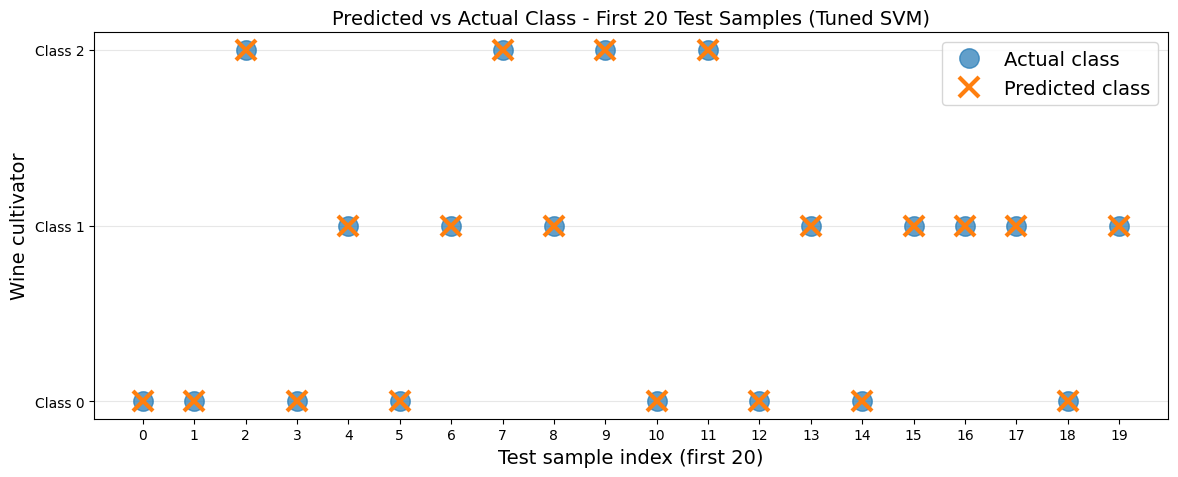

First 20 test samples: 20/20 correct
Full test set: 44/45 correct (0.9778)


In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Best model from the randomized search
y_pred = rnd_search_cv.best_estimator_.predict(X_test)

n = 20
idx = np.arange(n)
actual = np.array(y_test)[:n]
predicted = np.array(y_pred)[:n]

plt.figure(figsize=(12, 5))
plt.plot(idx, actual, 'o', markersize=14, label='Actual class', alpha=0.7)
plt.plot(idx, predicted, 'x', markersize=14, markeredgewidth=3,
         label='Predicted class')

# Shade any mismatches
for i in range(n):
    if actual[i] != predicted[i]:
        plt.axvspan(i - 0.4, i + 0.4, color='red', alpha=0.15)

plt.xticks(idx)
plt.yticks([0, 1, 2], ['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Test sample index (first 20)')
plt.ylabel('Wine cultivator')
plt.title('Predicted vs Actual Class - First 20 Test Samples (Tuned SVM)')
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"First {n} test samples: {(actual == predicted).sum()}/{n} correct")
print(f"Full test set: {(np.array(y_test) == y_pred).sum()}/{len(y_test)} correct "
      f"({rnd_search_cv.score(X_test, y_test):.4f})")

**3) Reflection**

**Give two real-world business or technology applications that you can use SVM on?**

**Answer:**

Medical diagnosis and biomarker classification. SVMs are widely used to classify tumors as malignant or benign, and to identify disease subtypes from gene-expression data. These problems look exactly like the Wine dataset scaled up: many measured features, relatively few patients. SVMs handle that shape well because the decision boundary depends only on the support vectors, not on the number of dimensions.

Fraud detection in financial transactions. Banks use SVMs to flag fraudulent credit card activity from features such as transaction amount, location, merchant type and timing. The margin-maximizing boundary tends to generalize well to new fraud patterns, and the kernelized version can capture the nonlinear interactions between features that simple rule-based systems miss.

**What is the difference between LinearSVC vs kernelized SVM**

**Answer:**

LinearSVC fits a straight hyperplane in the original feature space using the liblinear solver. It scales roughly linearly with the number of samples, making it the right choice for large datasets, and it has essentially one hyperparameter (C) to tune. Its limitation is that it cannot represent a curved boundary at all.

A kernelized SVM (SVC with an RBF or polynomial kernel) uses the kernel trick to find a linear boundary in an implicit higher-dimensional space, which corresponds to a nonlinear boundary in the original space. It is far more flexible but has more hyperparameters (C and gamma), and training scales between quadratically and cubically with sample count, so it becomes slow on large data.

What this exercise showed concretely: once the features were scaled, the three cultivators were nearly linearly separable, so LinearSVC already reached 97.7%. The default kernelized SVC actually did slightly worse at 97.0%. Only after tuning C and gamma did the kernelized version pull ahead, reaching 99.3% in cross-validation and 97.8% on the test set. The lesson is that a more powerful model is not automatically a better one — it has to be tuned, and on well-separated data the simpler model may be entirely sufficient.

**Why would you want to visualize the predicted vs actual results at the end the program?**

**Answer:**

An accuracy number tells you how often the model is right but nothing about where or how it fails. Here the score is 0.97778 — the visualization is what reveals that this means one specific wine out of 45 was misclassified, and which class it was confused with. That distinction matters: if every error is class_1 being mistaken for class_2, those two cultivators may be chemically similar, which is a different and more actionable finding than errors scattered at random.

It also makes the result legible to a non-technical audience who will not interpret a decimal, and it acts as a sanity check — if the predictions were misaligned with the labels because of an indexing bug, or if the model were predicting one class for everything, the chart would make that obvious immediately in a way the accuracy score might not.

**Write a statement on how you used AI in this assignment.**

**Answer:**

I used AI (Gemini inside Colab, and ChatGpt) throughout this assignment. I used it to interpret the wine.DESCR output and confirm that the three target classes represent three different cultivators rather than quality grades. When LinearSVC produced a ConvergenceWarning, I asked the AI to explain the cause; it pointed me to the mismatched feature scales rather than the iteration count, which I then verified myself by comparing the ranges of proline (278-1680) and hue (0.48-1.71) in the description output, and by observing that max_iter=1_000_000 still failed to converge. I used AI to help me explain the kernel trick and the roles of C and gamma in my own words, and to help me write and debug the matplotlib code for the prediction-vs-actual visualization. I also used it to check my interpretation of why the test score (0.9778) came out lower than the cross-validation best score (0.9926). I ran every cell myself, verified that the numbers in my written answers matched my actual outputs, and rewrote the explanations in my own words rather than pasting them.

## 11.